In [6]:
import sqlite3

# 데이터베이스 연결
conn = sqlite3.connect("stock_data.db")
cursor = conn.cursor()

# 테이블이 존재하는지 확인
cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name='stock_data';")
table_exists = cursor.fetchone()

# 테이블이 없으면 새로 생성
if not table_exists:
    cursor.execute("""
        CREATE TABLE stock_data (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            Ticker TEXT,
            Date TEXT,
            Open REAL,
            High REAL,
            Low REAL,
            Close REAL,
            Volume INTEGER
        );
    """)
    conn.commit()
    print("✅ 'stock_data' 테이블이 새로 생성되었습니다!")
else:
    print("✅ 'stock_data' 테이블이 이미 존재합니다!")

conn.close()


✅ 'stock_data' 테이블이 이미 존재합니다!


In [7]:
import sqlite3

conn = sqlite3.connect("stock_data.db")
cursor = conn.cursor()

# 기존 테이블 삭제
cursor.execute("DROP TABLE IF EXISTS stock_data;")
conn.commit()

# 새로운 테이블 생성 (Dividends 컬럼 포함)
cursor.execute("""
    CREATE TABLE stock_data (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        Ticker TEXT,
        Date TEXT,
        Open REAL,
        High REAL,
        Low REAL,
        Close REAL,
        Volume INTEGER,
        Dividends REAL
    );
""")
conn.commit()

print("✅ 기존 테이블 삭제 후, 새 테이블 생성 완료!")
conn.close()


✅ 기존 테이블 삭제 후, 새 테이블 생성 완료!


In [9]:
import yfinance as yf
import pandas as pd

# 주식 데이터 가져오는 함수
def fetch_stock_data(ticker, period="1mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df["Ticker"] = ticker  # 종목명 추가
    df.reset_index(inplace=True)  # 인덱스 초기화 (Date 컬럼을 따로 저장)
    return df

# 애플(AAPL) 주식 데이터 가져오기
df = fetch_stock_data("AAPL")

# 데이터 확인
print(df.head())


                       Date        Open        High         Low       Close  \
0 2025-01-22 00:00:00-05:00  219.548596  223.873842  219.548596  223.584167   
1 2025-01-23 00:00:00-05:00  224.493183  226.780662  222.055861  223.414368   
2 2025-01-24 00:00:00-05:00  224.533128  225.382200  221.166834  222.535324   
3 2025-01-27 00:00:00-05:00  223.773962  231.895022  223.733997  229.607544   
4 2025-01-28 00:00:00-05:00  230.596471  239.926210  230.556507  237.998322   

     Volume  Dividends  Stock Splits Ticker  
0  64126500        0.0           0.0   AAPL  
1  60234800        0.0           0.0   AAPL  
2  54697900        0.0           0.0   AAPL  
3  94863400        0.0           0.0   AAPL  
4  75707600        0.0           0.0   AAPL  


In [11]:
import sqlite3

# 데이터베이스 연결
conn = sqlite3.connect("stock_data.db")
cursor = conn.cursor()

# 'Stock Splits' 컬럼 추가
cursor.execute("ALTER TABLE stock_data ADD COLUMN `Stock Splits` REAL;")
conn.commit()

print("✅ 'Stock Splits' 컬럼 추가 완료!")
conn.close()


✅ 'Stock Splits' 컬럼 추가 완료!


In [14]:
import sqlite3

# 데이터베이스 연결
conn = sqlite3.connect("stock_data.db")

# 데이터를 테이블에 추가
df.to_sql("stock_data", conn, if_exists="append", index=False)

print("✅ 데이터가 성공적으로 저장되었습니다!")

conn.close()


✅ 데이터가 성공적으로 저장되었습니다!


In [16]:
# 데이터베이스 연결
conn = sqlite3.connect("stock_data.db")

# 데이터 조회
df_db = pd.read_sql("SELECT * FROM stock_data", conn)

# 데이터 확인
print(df_db.head())

conn.close()


   id Ticker                       Date        Open        High         Low  \
0   1   AAPL  2025-01-22 00:00:00-05:00  219.548596  223.873842  219.548596   
1   2   AAPL  2025-01-23 00:00:00-05:00  224.493183  226.780662  222.055861   
2   3   AAPL  2025-01-24 00:00:00-05:00  224.533128  225.382200  221.166834   
3   4   AAPL  2025-01-27 00:00:00-05:00  223.773962  231.895022  223.733997   
4   5   AAPL  2025-01-28 00:00:00-05:00  230.596471  239.926210  230.556507   

        Close    Volume  Dividends  Stock Splits  
0  223.584167  64126500        0.0           0.0  
1  223.414368  60234800        0.0           0.0  
2  222.535324  54697900        0.0           0.0  
3  229.607544  94863400        0.0           0.0  
4  237.998322  75707600        0.0           0.0  


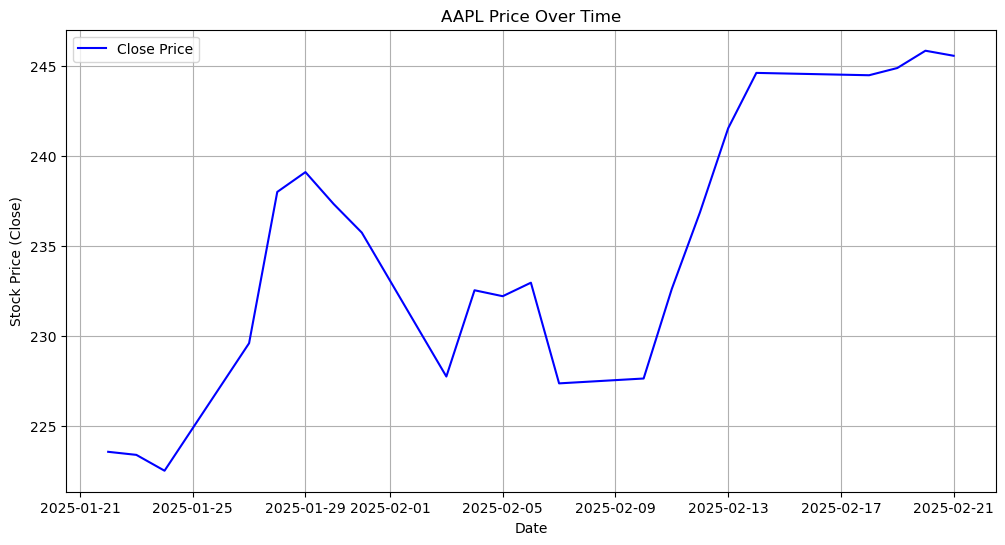

In [18]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 데이터베이스 연결
conn = sqlite3.connect("stock_data.db")

# 데이터 조회
df = pd.read_sql("SELECT Date, Close FROM stock_data", conn)
df["Date"] = pd.to_datetime(df["Date"])  # 날짜 변환
df.set_index("Date", inplace=True)  # 날짜를 인덱스로 설정

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Close"], label="Close Price", color="blue")

# 그래프 꾸미기
plt.xlabel("Date")
plt.ylabel("Stock Price (Close)")
plt.title("AAPL Price Over Time")
plt.legend()
plt.grid()

# 출력
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# 이동 평균선 (5일, 20일)
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# 상대 강도 지수 (RSI) 계산 (14일 기준)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD 지표 계산 (12, 26일 기준)
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()


In [ ]:
pip install tensorflow


2025-02-24 07:37:26.404571: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 07:37:26.848389: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 07:37:27.146926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740382647.457616     144 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740382647.560210     144 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-24 07:37:28.326739: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Epoch 1/10



2025-02-24 07:37:36.169685: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/8f684b08-a678-40f2-b613-08906f8af92a/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0979
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0104
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0064
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0053
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0051
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0043
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0045
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0048
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0048
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0041
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


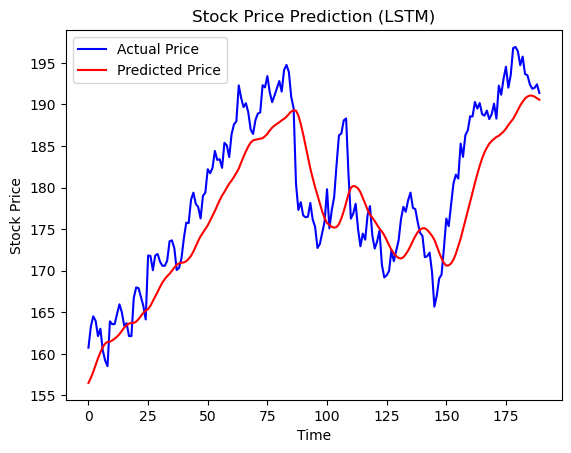

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# 주식 데이터 다운로드 (예: 애플)
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# 데이터 전처리
df = df[['Close']]  # 종가만 사용
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# 데이터셋 생성 (슬라이딩 윈도우 방식)
def create_dataset(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# 데이터 준비
window_size = 60  # 60일을 기준으로 예측
X, y = create_dataset(scaled_data, window_size)

# 데이터 차원 변경 (LSTM 입력 형태: [samples, timesteps, features])
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# LSTM 모델 정의
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # 예측하려는 값은 종가

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error')

# 모델 훈련
model.fit(X_train, y_train, epochs=10, batch_size=32)

# 예측
predictions = model.predict(X_test)

# 예측값 역변환
predictions = scaler.inverse_transform(predictions)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 예측 결과 출력
import matplotlib.pyplot as plt
plt.plot(y_test, color='blue', label='Actual Price')
plt.plot(predictions, color='red', label='Predicted Price')
plt.title('Stock Price Prediction (LSTM)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()


In [5]:
# y_test를 다시 변환
y_test_reshaped = y_test.reshape(-1, 1)  # 2D 배열로 변환
y_test_original = scaler.inverse_transform(y_test_reshaped)  # 역변환

# 성능 평가
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# MSE, RMSE 계산
mse = mean_squared_error(y_test_original, predictions)
rmse = np.sqrt(mse)

# MAPE 계산 (백분율 변환)
mape = mean_absolute_percentage_error(y_test_original, predictions) * 100

# R² Score 계산
r2 = r2_score(y_test_original, predictions)

# 결과 출력
print(f"📊 Mean Squared Error (MSE): {mse:.2f}")
print(f"📊 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📊 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"📊 R² Score: {r2:.4f}")


📊 Mean Squared Error (MSE): 647520239.33
📊 Root Mean Squared Error (RMSE): 25446.42
📊 Mean Absolute Percentage Error (MAPE): 99.31%
📊 R² Score: -331.7023


In [7]:
# 🔄 데이터 분할 방식 변경
train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

# LSTM 입력 데이터 생성
X_train, y_train = create_dataset(train_data, window_size)
X_test, y_test = create_dataset(test_data, window_size)

# 차원 변경
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# ✅ 모델 재설계 및 학습
model = Sequential()
model.add(LSTM(units=100, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# 모델 컴파일 및 학습
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=50, batch_size=32)

# 예측 및 역변환 (차원 맞추기)
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# ✅ 성능 평가
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, predictions) * 100
r2 = r2_score(y_test, predictions)

# 결과 출력
print(f"📊 Mean Squared Error (MSE): {mse:.2f}")
print(f"📊 Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"📊 Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"📊 R² Score: {r2:.4f}")


Epoch 1/50


/home/8f684b08-a678-40f2-b613-08906f8af92a/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.1115
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0068
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0040
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0035
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0028
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0029
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0026
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0027
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0030
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0028
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0029
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0028
Epoch 13/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0026
Epoch 14/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0027
Epoch 15/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0027
Epoch 16/50
24/

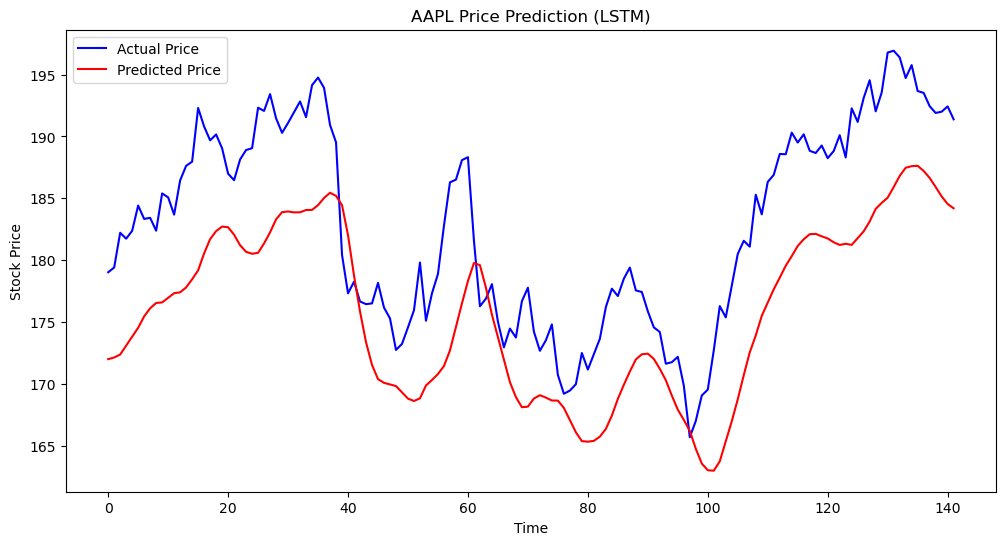

In [11]:
import matplotlib.pyplot as plt

# 그래프 시각화
plt.figure(figsize=(12,6))
plt.plot(y_test, color='blue', label='Actual Price')  # 실제 주가
plt.plot(predictions, color='red', label='Predicted Price')  # 예측 주가
plt.title('AAPL Price Prediction (LSTM)')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()
